# Chapter 4.5: Knowledge Distillation for Ranking

## Learning Objectives

By the end of this notebook, you will be able to:

1. Implement **teacher-student** frameworks for CTR model compression
2. Build a **privileged features distillation** pipeline where the teacher uses features unavailable at serving
3. Compare **logit matching** vs **feature matching** vs **attention transfer** strategies
4. Understand Tencent's ranking distillation system architecture
5. Implement **self-distillation** and **online distillation** techniques
6. Evaluate the accuracy-latency trade-offs of distilled models
7. Design distillation pipelines suitable for production deployment

## Prerequisites

- Understanding of knowledge distillation basics (Hinton et al., 2015)
- Familiarity with CTR prediction models
- Knowledge of model compression techniques

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part4/chapter_4.5_distillation.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://github.com/hideak1/rec_system/raw/main/notebooks/part4/chapter_4.5_distillation.ipynb)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Optional, Tuple
import copy

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
device = torch.device('cpu')

PyTorch version: 2.2.2


## 1. Why Distillation for Ranking?

In production ranking systems, we face a fundamental tension:
- **Training**: Can use large models, many features, long sequences, complex architectures
- **Serving**: Must meet strict latency requirements (often <10ms per item)

Knowledge distillation bridges this gap by transferring knowledge from a powerful teacher to a lightweight student.

### Ranking-Specific Distillation Challenges

1. **Privileged features**: Teacher can use features not available at serving time (e.g., real-time user context, post-interaction signals)
2. **Calibration**: Teacher's soft labels provide richer information than binary click/no-click labels
3. **List-level knowledge**: Teacher can capture cross-item interactions that the student cannot

$$\mathcal{L}_{\text{distill}} = \alpha \cdot \mathcal{L}_{\text{hard}} + (1-\alpha) \cdot \mathcal{L}_{\text{soft}}$$

where $\mathcal{L}_{\text{hard}}$ is the ground-truth loss and $\mathcal{L}_{\text{soft}}$ is the distillation loss.

In [2]:
def generate_distillation_data(num_samples=10000, num_sparse=8, num_dense=5,
                                num_privileged=3, vocab_sizes=None, seed=42):
    """Generate CTR data with privileged features (available only to teacher).
    
    Privileged features represent real-time signals available during training
    but not at serving time.
    """
    np.random.seed(seed)
    if vocab_sizes is None:
        vocab_sizes = [100, 200, 50, 300, 80, 150, 60, 120]
    
    sparse = np.column_stack([np.random.randint(0, vs, size=num_samples) for vs in vocab_sizes])
    dense = np.random.randn(num_samples, num_dense).astype(np.float32)
    
    # Privileged features (only available to teacher during training)
    privileged = np.random.randn(num_samples, num_privileged).astype(np.float32)
    
    # Labels depend on both regular and privileged features
    logits = 0.1 * dense.sum(axis=1) + 0.3 * privileged.sum(axis=1)
    for i in range(min(3, num_sparse)):
        logits += 0.05 * (sparse[:, i] % 10 - 5)
    logits += 0.15 * dense[:, 0] * privileged[:, 0]  # Interaction
    probs = 1 / (1 + np.exp(-logits))
    labels = (np.random.rand(num_samples) < probs).astype(np.float32)
    
    return {
        'sparse': torch.LongTensor(sparse),
        'dense': torch.FloatTensor(dense),
        'privileged': torch.FloatTensor(privileged),
        'labels': torch.FloatTensor(labels)
    }


VOCAB_SIZES = [100, 200, 50, 300, 80, 150, 60, 120]
NUM_SPARSE = 8
NUM_DENSE = 5
NUM_PRIVILEGED = 3
EMBED_DIM = 16

train_data = generate_distillation_data(10000)
test_data = generate_distillation_data(2000, seed=99)

print(f"Training samples: {len(train_data['labels'])}, CTR: {train_data['labels'].mean():.3f}")
print(f"Test samples: {len(test_data['labels'])}, CTR: {test_data['labels'].mean():.3f}")

Training samples: 10000, CTR: 0.486
Test samples: 2000, CTR: 0.484


## 2. Teacher and Student Models

The **teacher** is a large model with access to all features (including privileged ones). The **student** is a compact model that only uses features available at serving time.

In [3]:
class TeacherModel(nn.Module):
    """Large teacher model with privileged features."""
    def __init__(self, vocab_sizes, embed_dim, num_dense, num_privileged,
                 hidden_dims=None):
        super().__init__()
        self.embeddings = nn.ModuleList([nn.Embedding(vs, embed_dim) for vs in vocab_sizes])
        
        input_dim = embed_dim * len(vocab_sizes) + num_dense + num_privileged
        if hidden_dims is None:
            hidden_dims = [512, 256, 128, 64]
        
        layers = []
        prev = input_dim
        self.hidden_outputs = []  # For feature distillation
        for dim in hidden_dims:
            layers.extend([nn.Linear(prev, dim), nn.ReLU(), nn.Dropout(0.1)])
            prev = dim
        self.mlp = nn.Sequential(*layers)
        self.output = nn.Linear(prev, 1)
        self.hidden_dims = hidden_dims
    
    def forward(self, sparse, dense, privileged, return_hidden=False):
        embeds = [self.embeddings[i](sparse[:, i]) for i in range(sparse.size(1))]
        x = torch.cat(embeds + [dense, privileged], dim=-1)
        
        if return_hidden:
            hiddens = []
            for i, layer in enumerate(self.mlp):
                x = layer(x)
                if isinstance(layer, nn.ReLU):
                    hiddens.append(x)
            logit = self.output(x).squeeze(-1)
            return logit, hiddens
        
        h = self.mlp(x)
        return self.output(h).squeeze(-1)


class StudentModel(nn.Module):
    """Compact student model without privileged features."""
    def __init__(self, vocab_sizes, embed_dim, num_dense, hidden_dims=None):
        super().__init__()
        self.embeddings = nn.ModuleList([nn.Embedding(vs, embed_dim) for vs in vocab_sizes])
        
        input_dim = embed_dim * len(vocab_sizes) + num_dense
        if hidden_dims is None:
            hidden_dims = [128, 64]
        
        layers = []
        prev = input_dim
        for dim in hidden_dims:
            layers.extend([nn.Linear(prev, dim), nn.ReLU(), nn.Dropout(0.1)])
            prev = dim
        self.mlp = nn.Sequential(*layers)
        self.output = nn.Linear(prev, 1)
        self.hidden_dims = hidden_dims
    
    def forward(self, sparse, dense, return_hidden=False):
        embeds = [self.embeddings[i](sparse[:, i]) for i in range(sparse.size(1))]
        x = torch.cat(embeds + [dense], dim=-1)
        
        if return_hidden:
            hiddens = []
            for i, layer in enumerate(self.mlp):
                x = layer(x)
                if isinstance(layer, nn.ReLU):
                    hiddens.append(x)
            logit = self.output(x).squeeze(-1)
            return logit, hiddens
        
        h = self.mlp(x)
        return self.output(h).squeeze(-1)


teacher = TeacherModel(VOCAB_SIZES, EMBED_DIM, NUM_DENSE, NUM_PRIVILEGED)
student = StudentModel(VOCAB_SIZES, EMBED_DIM, NUM_DENSE)

print(f"Teacher parameters: {sum(p.numel() for p in teacher.parameters()):,}")
print(f"Student parameters: {sum(p.numel() for p in student.parameters()):,}")
print(f"Compression ratio: {sum(p.numel() for p in teacher.parameters()) / sum(p.numel() for p in student.parameters()):.1f}x")

Teacher parameters: 259,649
Student parameters: 42,433
Compression ratio: 6.1x


## 3. Train the Teacher

First, train the teacher model with all features including privileged ones.

In [4]:
def train_teacher(model, data, epochs=20, batch_size=256, lr=1e-3):
    """Train teacher model with all features."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    n = len(data['labels'])
    history = []
    
    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n)
        total_loss = 0
        count = 0
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            optimizer.zero_grad()
            logits = model(data['sparse'][idx], data['dense'][idx], data['privileged'][idx])
            loss = criterion(logits, data['labels'][idx])
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            count += 1
        history.append(total_loss / count)
    
    return history


def evaluate_model(model, data, use_privileged=False):
    """Evaluate model AUC."""
    model.eval()
    with torch.no_grad():
        if use_privileged:
            logits = model(data['sparse'], data['dense'], data['privileged'])
        else:
            logits = model(data['sparse'], data['dense'])
        preds = torch.sigmoid(logits).numpy()
        labels = data['labels'].numpy()
        
        pos = preds[labels == 1]
        neg = preds[labels == 0]
        if len(pos) > 0 and len(neg) > 0:
            auc = np.mean(pos[:, None] > neg[None, :200])
        else:
            auc = 0.5
    return auc


teacher_history = train_teacher(teacher, train_data)
teacher_auc = evaluate_model(teacher, test_data, use_privileged=True)
print(f"Teacher AUC: {teacher_auc:.4f}")

Teacher AUC: 0.5591


## 4. Distillation Strategies

### 4.1 Logit Matching

The simplest form: match student logits to teacher logits.

$$\mathcal{L}_{\text{logit}} = \text{MSE}(z_s, z_t)$$

or with temperature scaling:

$$\mathcal{L}_{\text{soft}} = \text{KL}(\sigma(z_t / \tau) \| \sigma(z_s / \tau)) \cdot \tau^2$$

### 4.2 Feature Matching

Match intermediate representations of teacher and student.

$$\mathcal{L}_{\text{feat}} = \sum_l \| f_l^s(\mathbf{x}) - g(f_l^t(\mathbf{x})) \|^2$$

where $g$ is a learnable projection to match dimensions.

> **🔑 Pro Tip:** In ranking distillation, logit matching tends to work better than feature matching because the teacher's soft predictions encode richer ordering information than intermediate features.

In [5]:
class DistillationTrainer:
    """Knowledge distillation trainer for ranking models."""
    def __init__(self, teacher, student, alpha=0.5, temperature=3.0,
                 distill_mode='logit'):
        self.teacher = teacher
        self.student = student
        self.alpha = alpha
        self.temperature = temperature
        self.distill_mode = distill_mode
        
        # Feature matching projections (if needed)
        if distill_mode == 'feature':
            self.projections = nn.ModuleList([
                nn.Linear(s_dim, t_dim)
                for s_dim, t_dim in zip(student.hidden_dims, teacher.hidden_dims[:len(student.hidden_dims)])
            ])
        else:
            self.projections = None
    
    def logit_distillation_loss(self, student_logits, teacher_logits):
        """KL divergence between soft predictions."""
        T = self.temperature
        student_soft = torch.sigmoid(student_logits / T)
        teacher_soft = torch.sigmoid(teacher_logits / T)
        
        # Binary KL divergence
        loss = teacher_soft * torch.log(teacher_soft / (student_soft + 1e-8) + 1e-8) + \
               (1 - teacher_soft) * torch.log((1 - teacher_soft) / (1 - student_soft + 1e-8) + 1e-8)
        return loss.mean() * T * T
    
    def feature_distillation_loss(self, student_hiddens, teacher_hiddens):
        """MSE loss between projected student and teacher hidden states."""
        loss = 0
        num_layers = min(len(student_hiddens), len(teacher_hiddens))
        for i in range(num_layers):
            projected = self.projections[i](student_hiddens[i])
            loss += F.mse_loss(projected, teacher_hiddens[i].detach())
        return loss / max(num_layers, 1)
    
    def train_step(self, batch, optimizer):
        """Single training step."""
        sparse, dense, privileged, labels = (
            batch['sparse'], batch['dense'], batch['privileged'], batch['labels']
        )
        
        # Teacher forward (no grad)
        self.teacher.eval()
        with torch.no_grad():
            if self.distill_mode == 'feature':
                teacher_logits, teacher_hiddens = self.teacher(
                    sparse, dense, privileged, return_hidden=True
                )
            else:
                teacher_logits = self.teacher(sparse, dense, privileged)
        
        # Student forward
        self.student.train()
        if self.distill_mode == 'feature':
            student_logits, student_hiddens = self.student(
                sparse, dense, return_hidden=True
            )
        else:
            student_logits = self.student(sparse, dense)
        
        # Hard loss (ground truth)
        hard_loss = F.binary_cross_entropy_with_logits(student_logits, labels)
        
        # Soft loss (distillation)
        if self.distill_mode == 'logit':
            soft_loss = self.logit_distillation_loss(student_logits, teacher_logits)
        elif self.distill_mode == 'feature':
            soft_loss = self.feature_distillation_loss(student_hiddens, teacher_hiddens)
        elif self.distill_mode == 'both':
            soft_loss = self.logit_distillation_loss(student_logits, teacher_logits) + \
                        0.5 * self.feature_distillation_loss(student_hiddens, teacher_hiddens)
        else:
            soft_loss = torch.tensor(0.0)
        
        total_loss = self.alpha * hard_loss + (1 - self.alpha) * soft_loss
        
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        
        return total_loss.item(), hard_loss.item(), soft_loss.item()


def train_with_distillation(teacher, student, train_data, test_data,
                             distill_mode='logit', alpha=0.5, temperature=3.0,
                             epochs=20, batch_size=256, lr=1e-3):
    """Full distillation training loop."""
    trainer = DistillationTrainer(teacher, student, alpha, temperature, distill_mode)
    params = list(student.parameters())
    if trainer.projections is not None:
        params += list(trainer.projections.parameters())
    optimizer = torch.optim.Adam(params, lr=lr)
    
    n = len(train_data['labels'])
    history = {'total_loss': [], 'hard_loss': [], 'soft_loss': [], 'test_auc': []}
    
    for epoch in range(epochs):
        perm = torch.randperm(n)
        epoch_total, epoch_hard, epoch_soft = 0, 0, 0
        count = 0
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            batch = {k: v[idx] for k, v in train_data.items()}
            t, h, s = trainer.train_step(batch, optimizer)
            epoch_total += t
            epoch_hard += h
            epoch_soft += s
            count += 1
        
        history['total_loss'].append(epoch_total / count)
        history['hard_loss'].append(epoch_hard / count)
        history['soft_loss'].append(epoch_soft / count)
        
        auc = evaluate_model(student, test_data, use_privileged=False)
        history['test_auc'].append(auc)
    
    return history


# Train student with different distillation strategies
results = {}

# Baseline: student without distillation
torch.manual_seed(42)
student_baseline = StudentModel(VOCAB_SIZES, EMBED_DIM, NUM_DENSE)
baseline_history = train_with_distillation(
    teacher, student_baseline, train_data, test_data,
    distill_mode='none', alpha=1.0
)
results['No Distillation'] = baseline_history

# Logit matching
torch.manual_seed(42)
student_logit = StudentModel(VOCAB_SIZES, EMBED_DIM, NUM_DENSE)
logit_history = train_with_distillation(
    teacher, student_logit, train_data, test_data,
    distill_mode='logit', alpha=0.3, temperature=3.0
)
results['Logit Matching'] = logit_history

# Feature matching
torch.manual_seed(42)
student_feat = StudentModel(VOCAB_SIZES, EMBED_DIM, NUM_DENSE)
feat_history = train_with_distillation(
    teacher, student_feat, train_data, test_data,
    distill_mode='feature', alpha=0.3
)
results['Feature Matching'] = feat_history

print("\nFinal Test AUC:")
print(f"  Teacher:          {teacher_auc:.4f}")
for name, hist in results.items():
    print(f"  {name:20s} {hist['test_auc'][-1]:.4f}")


Final Test AUC:
  Teacher:          0.5591
  No Distillation      0.5126
  Logit Matching       0.5057
  Feature Matching     0.4888


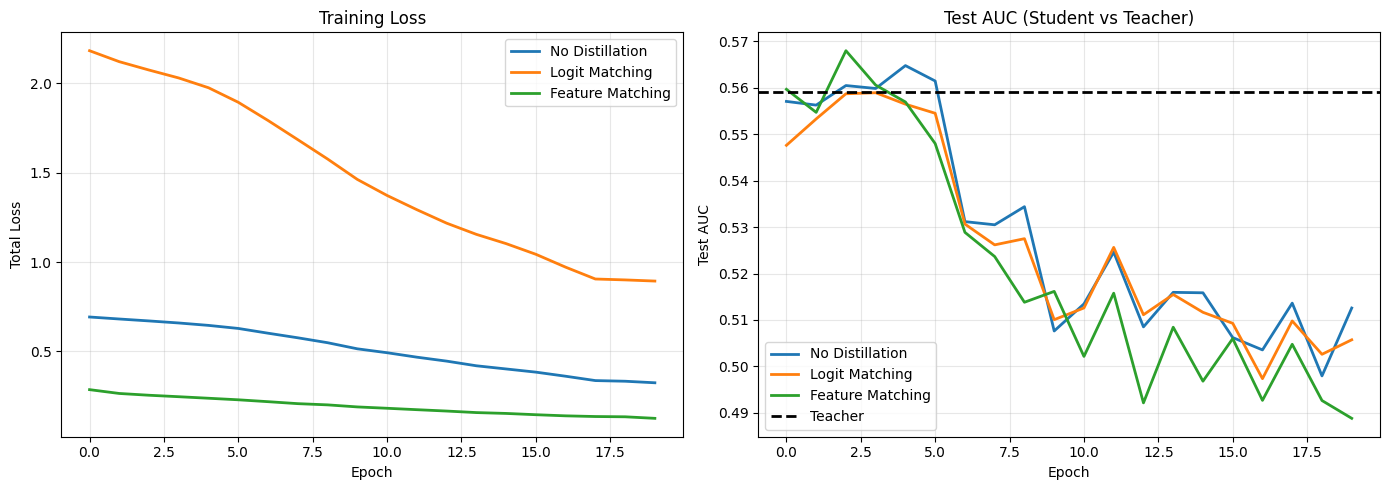

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, hist in results.items():
    axes[0].plot(hist['total_loss'], label=name, linewidth=2)
    axes[1].plot(hist['test_auc'], label=name, linewidth=2)

axes[1].axhline(y=teacher_auc, color='k', linestyle='--', label='Teacher', linewidth=2)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Test AUC')
axes[1].set_title('Test AUC (Student vs Teacher)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Privileged Features Distillation

A particularly important pattern in ranking: the teacher uses **privileged features** that are not available at serving time.

### Examples of Privileged Features
- Real-time user session context (requires complex real-time computation)
- Post-click engagement signals (available only after interaction)
- Cross-device user features (privacy constraints at serving)
- Complex user behavior sequences (too expensive to compute in real-time)

> **💡 Concept:** Privileged features distillation is uniquely valuable in ranking because it allows the student to implicitly benefit from information it can never directly access, effectively creating a better model than could be trained on the student's feature set alone.

In [7]:
class PrivilegedDistillation(nn.Module):
    """Privileged features distillation with separate distillation paths.
    
    The teacher has a privileged path and a shared path.
    Distillation transfers knowledge from the privileged path
    to the student's representations.
    """
    def __init__(self, teacher, student, bridge_dim=64):
        super().__init__()
        self.teacher = teacher
        self.student = student
        
        # Bridge network: maps student features to teacher's representation space
        student_last_dim = student.hidden_dims[-1]
        teacher_last_dim = teacher.hidden_dims[-1]
        self.bridge = nn.Sequential(
            nn.Linear(student_last_dim, bridge_dim),
            nn.ReLU(),
            nn.Linear(bridge_dim, teacher_last_dim)
        )
    
    def compute_distillation_loss(self, sparse, dense, privileged, labels):
        # Teacher: get final hidden state
        self.teacher.eval()
        with torch.no_grad():
            teacher_logits, teacher_hiddens = self.teacher(
                sparse, dense, privileged, return_hidden=True
            )
            teacher_repr = teacher_hiddens[-1]  # Last hidden layer
        
        # Student: get final hidden state
        self.student.train()
        student_logits, student_hiddens = self.student(
            sparse, dense, return_hidden=True
        )
        student_repr = student_hiddens[-1]
        
        # Bridge alignment loss
        bridged_repr = self.bridge(student_repr)
        repr_loss = F.mse_loss(bridged_repr, teacher_repr.detach())
        
        # Logit distillation
        T = 3.0
        student_soft = torch.sigmoid(student_logits / T)
        teacher_soft = torch.sigmoid(teacher_logits / T).detach()
        logit_loss = F.mse_loss(student_soft, teacher_soft) * T * T
        
        # Hard loss
        hard_loss = F.binary_cross_entropy_with_logits(student_logits, labels)
        
        return 0.3 * hard_loss + 0.4 * logit_loss + 0.3 * repr_loss


# Train with privileged distillation
torch.manual_seed(42)
student_priv = StudentModel(VOCAB_SIZES, EMBED_DIM, NUM_DENSE)
priv_distill = PrivilegedDistillation(teacher, student_priv)
optimizer = torch.optim.Adam(
    list(student_priv.parameters()) + list(priv_distill.bridge.parameters()),
    lr=1e-3
)

priv_history = []
n = len(train_data['labels'])
for epoch in range(20):
    perm = torch.randperm(n)
    total_loss = 0
    count = 0
    for i in range(0, n, 256):
        idx = perm[i:i+256]
        optimizer.zero_grad()
        loss = priv_distill.compute_distillation_loss(
            train_data['sparse'][idx], train_data['dense'][idx],
            train_data['privileged'][idx], train_data['labels'][idx]
        )
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        count += 1
    priv_history.append(evaluate_model(student_priv, test_data))

print(f"Privileged distillation AUC: {priv_history[-1]:.4f}")

Privileged distillation AUC: 0.5053


## 6. Self-Distillation and Online Distillation

### Self-Distillation
The model distills knowledge from its own deeper layers to shallower layers, or from a previous training epoch.

### Online Distillation
Multiple student models learn from each other simultaneously, without a separate pre-trained teacher.

$$\mathcal{L}_{\text{online}} = \mathcal{L}_{\text{task}} + \beta \cdot \text{KL}(p_1 \| p_2) + \beta \cdot \text{KL}(p_2 \| p_1)$$

> **⚠️ Common Pitfall:** Online distillation requires careful balancing. If one model dominates, the other may degrade, leading to a collapse where both models converge to a poor solution.

In [8]:
class SelfDistillation(nn.Module):
    """Self-distillation: deeper layers teach shallower layers."""
    def __init__(self, vocab_sizes, embed_dim, num_dense, hidden_dims=None):
        super().__init__()
        self.embeddings = nn.ModuleList([nn.Embedding(vs, embed_dim) for vs in vocab_sizes])
        
        input_dim = embed_dim * len(vocab_sizes) + num_dense
        if hidden_dims is None:
            hidden_dims = [256, 128, 64]
        
        self.layers = nn.ModuleList()
        prev = input_dim
        for dim in hidden_dims:
            self.layers.append(nn.Sequential(nn.Linear(prev, dim), nn.ReLU(), nn.Dropout(0.1)))
            prev = dim
        
        # Early exit classifiers (for self-distillation)
        self.classifiers = nn.ModuleList([
            nn.Linear(dim, 1) for dim in hidden_dims
        ])
    
    def forward(self, sparse, dense, return_all_logits=False):
        embeds = [self.embeddings[i](sparse[:, i]) for i in range(sparse.size(1))]
        x = torch.cat(embeds + [dense], dim=-1)
        
        all_logits = []
        for layer, classifier in zip(self.layers, self.classifiers):
            x = layer(x)
            all_logits.append(classifier(x).squeeze(-1))
        
        if return_all_logits:
            return all_logits
        return all_logits[-1]
    
    def self_distillation_loss(self, all_logits, labels, temperature=3.0):
        """Self-distillation: final layer teaches earlier layers."""
        # Hard loss for all classifiers
        hard_loss = sum(F.binary_cross_entropy_with_logits(logit, labels) for logit in all_logits)
        
        # Self-distillation: deeper teaches shallower
        teacher_logit = all_logits[-1].detach()
        teacher_soft = torch.sigmoid(teacher_logit / temperature)
        
        distill_loss = 0
        for logit in all_logits[:-1]:
            student_soft = torch.sigmoid(logit / temperature)
            distill_loss += F.mse_loss(student_soft, teacher_soft) * temperature ** 2
        
        return hard_loss + 0.5 * distill_loss


# Train self-distillation model
torch.manual_seed(42)
self_distill_model = SelfDistillation(VOCAB_SIZES, EMBED_DIM, NUM_DENSE)
optimizer = torch.optim.Adam(self_distill_model.parameters(), lr=1e-3)

sd_history = []
n = len(train_data['labels'])
for epoch in range(20):
    self_distill_model.train()
    perm = torch.randperm(n)
    total_loss = 0
    count = 0
    for i in range(0, n, 256):
        idx = perm[i:i+256]
        optimizer.zero_grad()
        all_logits = self_distill_model(train_data['sparse'][idx], train_data['dense'][idx], return_all_logits=True)
        loss = self_distill_model.self_distillation_loss(all_logits, train_data['labels'][idx])
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        count += 1
    
    # Evaluate all exits
    self_distill_model.eval()
    with torch.no_grad():
        all_logits = self_distill_model(test_data['sparse'], test_data['dense'], return_all_logits=True)
    
    exit_aucs = []
    for logit in all_logits:
        preds = torch.sigmoid(logit).numpy()
        labs = test_data['labels'].numpy()
        pos = preds[labs == 1]
        neg = preds[labs == 0]
        auc = np.mean(pos[:, None] > neg[None, :200]) if len(pos) > 0 and len(neg) > 0 else 0.5
        exit_aucs.append(auc)
    sd_history.append(exit_aucs)

print("\nSelf-Distillation Exit AUCs:")
for i, auc in enumerate(sd_history[-1]):
    print(f"  Exit {i} (layer {i+1}): {auc:.4f}")


Self-Distillation Exit AUCs:
  Exit 0 (layer 1): 0.5153
  Exit 1 (layer 2): 0.5016
  Exit 2 (layer 3): 0.5014


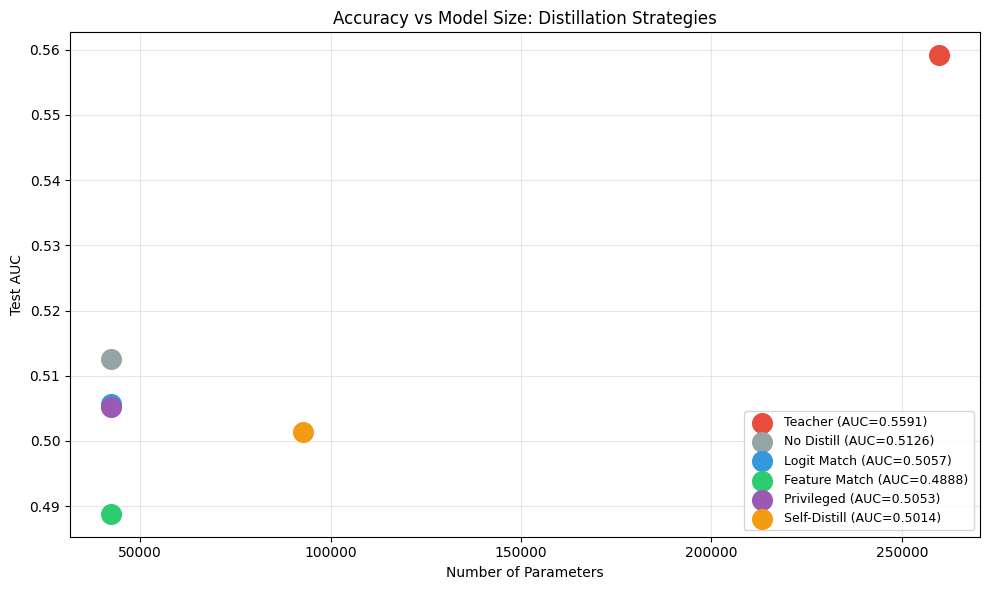

In [9]:
# Comprehensive comparison
fig, ax = plt.subplots(figsize=(10, 6))

methods = ['Teacher', 'No Distill', 'Logit Match', 'Feature Match', 'Privileged', 'Self-Distill']
aucs = [
    teacher_auc,
    results['No Distillation']['test_auc'][-1],
    results['Logit Matching']['test_auc'][-1],
    results['Feature Matching']['test_auc'][-1],
    priv_history[-1],
    sd_history[-1][-1]
]
param_counts = [
    sum(p.numel() for p in teacher.parameters()),
    sum(p.numel() for p in student_baseline.parameters()),
    sum(p.numel() for p in student_logit.parameters()),
    sum(p.numel() for p in student_feat.parameters()),
    sum(p.numel() for p in student_priv.parameters()),
    sum(p.numel() for p in self_distill_model.parameters()),
]

colors = ['#e74c3c', '#95a5a6', '#3498db', '#2ecc71', '#9b59b6', '#f39c12']
for i, (name, auc, params) in enumerate(zip(methods, aucs, param_counts)):
    ax.scatter(params, auc, s=200, c=colors[i], label=f'{name} (AUC={auc:.4f})', zorder=5)

ax.set_xlabel('Number of Parameters')
ax.set_ylabel('Test AUC')
ax.set_title('Accuracy vs Model Size: Distillation Strategies')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Exercises

### 🏋️ Exercise 1: Implement Privileged Feature Distillation Pipeline

Build a complete pipeline where the teacher uses user behavior sequences (privileged) while the student only uses user profile features.

In [10]:
class SequenceTeacher(nn.Module):
    """Teacher with access to user behavior sequence (privileged feature)."""
    def __init__(self, num_items, embed_dim, num_profile_features):
        super().__init__()
        # TODO: Implement teacher that uses:
        # 1. User profile features (shared with student)
        # 2. User behavior sequence (privileged - not available to student)
        # Use attention over behavior sequence
        pass
    
    def forward(self, profile_features, behavior_items, behavior_mask):
        # TODO: Encode both profile and behavior, combine for prediction
        pass


class ProfileStudent(nn.Module):
    """Student using only user profile features."""
    def __init__(self, num_profile_features, embed_dim):
        super().__init__()
        # TODO: Simple MLP on profile features
        pass
    
    def forward(self, profile_features):
        pass


# TODO:
# 1. Generate data with both profile and behavior features
# 2. Train teacher on both
# 3. Distill to student (profile only)
# 4. Compare: student with distillation vs student without

### 🏋️ Exercise 2: Temperature Sensitivity Analysis

Analyze how the distillation temperature affects student performance.

In [11]:
def temperature_analysis(teacher, train_data, test_data,
                          temperatures=[0.5, 1.0, 2.0, 3.0, 5.0, 10.0]):
    """Analyze the effect of distillation temperature on student performance.
    
    TODO:
    1. For each temperature, train a student with logit distillation
    2. Record final test AUC
    3. Plot temperature vs AUC curve
    4. Explain the observed relationship
    """
    pass


# TODO: Run analysis and plot results

### 🏋️ Exercise 3: Online Mutual Distillation

Implement online distillation where two models teach each other simultaneously.

In [12]:
def online_mutual_distillation(model_a, model_b, train_data, test_data,
                                epochs=20, beta=0.5, lr=1e-3):
    """Train two models that teach each other.
    
    Loss for model A:
        L_A = BCE(A(x), y) + beta * KL(B(x) || A(x))
    
    Loss for model B:
        L_B = BCE(B(x), y) + beta * KL(A(x) || B(x))
    
    TODO:
    1. Initialize two student-sized models with different architectures
    2. Train them jointly with mutual distillation
    3. Track and plot learning curves for both models
    4. Compare against training each model independently
    """
    pass


# TODO: Run online mutual distillation

## Summary

In this notebook, we explored knowledge distillation techniques for ranking:

| Method | Key Idea | Use Case |
|--------|----------|----------|
| **Logit matching** | Match soft predictions | General compression |
| **Feature matching** | Align intermediate representations | When hidden representations matter |
| **Privileged distillation** | Teacher uses extra features | Production with feature asymmetry |
| **Self-distillation** | Deeper layers teach shallower | Early-exit inference |
| **Online distillation** | Models teach each other | No pre-trained teacher available |

**Key takeaways:**
- Privileged features distillation is uniquely valuable in ranking systems
- Logit matching generally outperforms feature matching for CTR prediction
- Temperature controls the softness of teacher signals; typically T=2-5 works well
- Self-distillation enables efficient early-exit inference
- The optimal alpha (hard vs soft loss balance) depends on data quality and quantity